<a href="https://colab.research.google.com/github/anuskasthapit98/Machine-Learning/blob/practice/decision_trees_and_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
from sklearn.datasets import load_iris


iris= load_iris()

dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [28]:
import pandas as pd
df= pd.DataFrame(iris.data, columns= iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [29]:
df['target'] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
  df.drop(columns=['target']),iris.target,
   test_size=0.2
)

X_test.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
8,4.4,2.9,1.4,0.2
111,6.4,2.7,5.3,1.9
68,6.2,2.2,4.5,1.5
130,7.4,2.8,6.1,1.9
103,6.3,2.9,5.6,1.8


In [31]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(ccp_alpha=0.01, criterion='entropy')
clf = clf.fit(X_train, y_train)
clf.get_params()


{'ccp_alpha': 0.01,
 'class_weight': None,
 'criterion': 'entropy',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [32]:
predictions = clf.predict(X_test)
predictions

array([0, 2, 1, 2, 2, 0, 2, 0, 1, 2, 2, 1, 0, 0, 1, 2, 0, 0, 2, 2, 2, 1,
       2, 1, 1, 2, 0, 2, 0, 2])

In [33]:
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': predictions})
comparison_df.head()

,Actual,Predicted
0,0,0
1,2,2
2,1,1
3,2,2
4,2,2


In [34]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, predictions)

1.0

In [35]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, predictions,labels=[0,1,2])

array([[ 9,  0,  0],
       [ 0,  7,  0],
       [ 0,  0, 14]])

In [36]:
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions,target_names = ['setosa', 'versicolor', 'virginica']))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         9
  versicolor       1.00      1.00      1.00         7
   virginica       1.00      1.00      1.00        14

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [37]:
feature_names = iris.feature_names
feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [38]:
feature_importance = (pd.DataFrame(clf.feature_importances_,index= feature_names).sort_values(0,ascending=False))


feature_importance

,0
petal width (cm),0.686474
petal length (cm),0.299005
sepal width (cm),0.014521
sepal length (cm),0.000000


<Axes: >

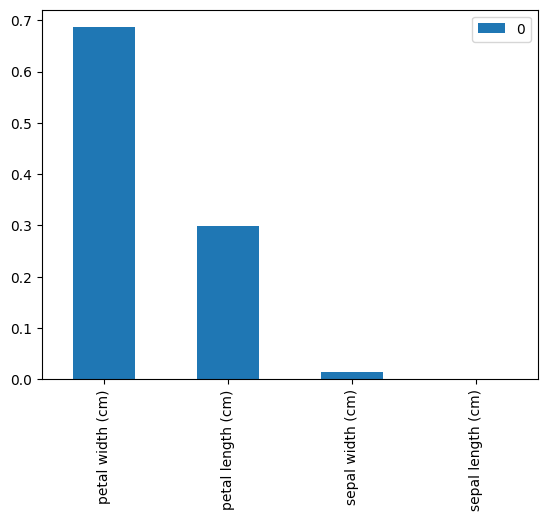

In [39]:
feature_importance.head(10).plot(kind='bar')

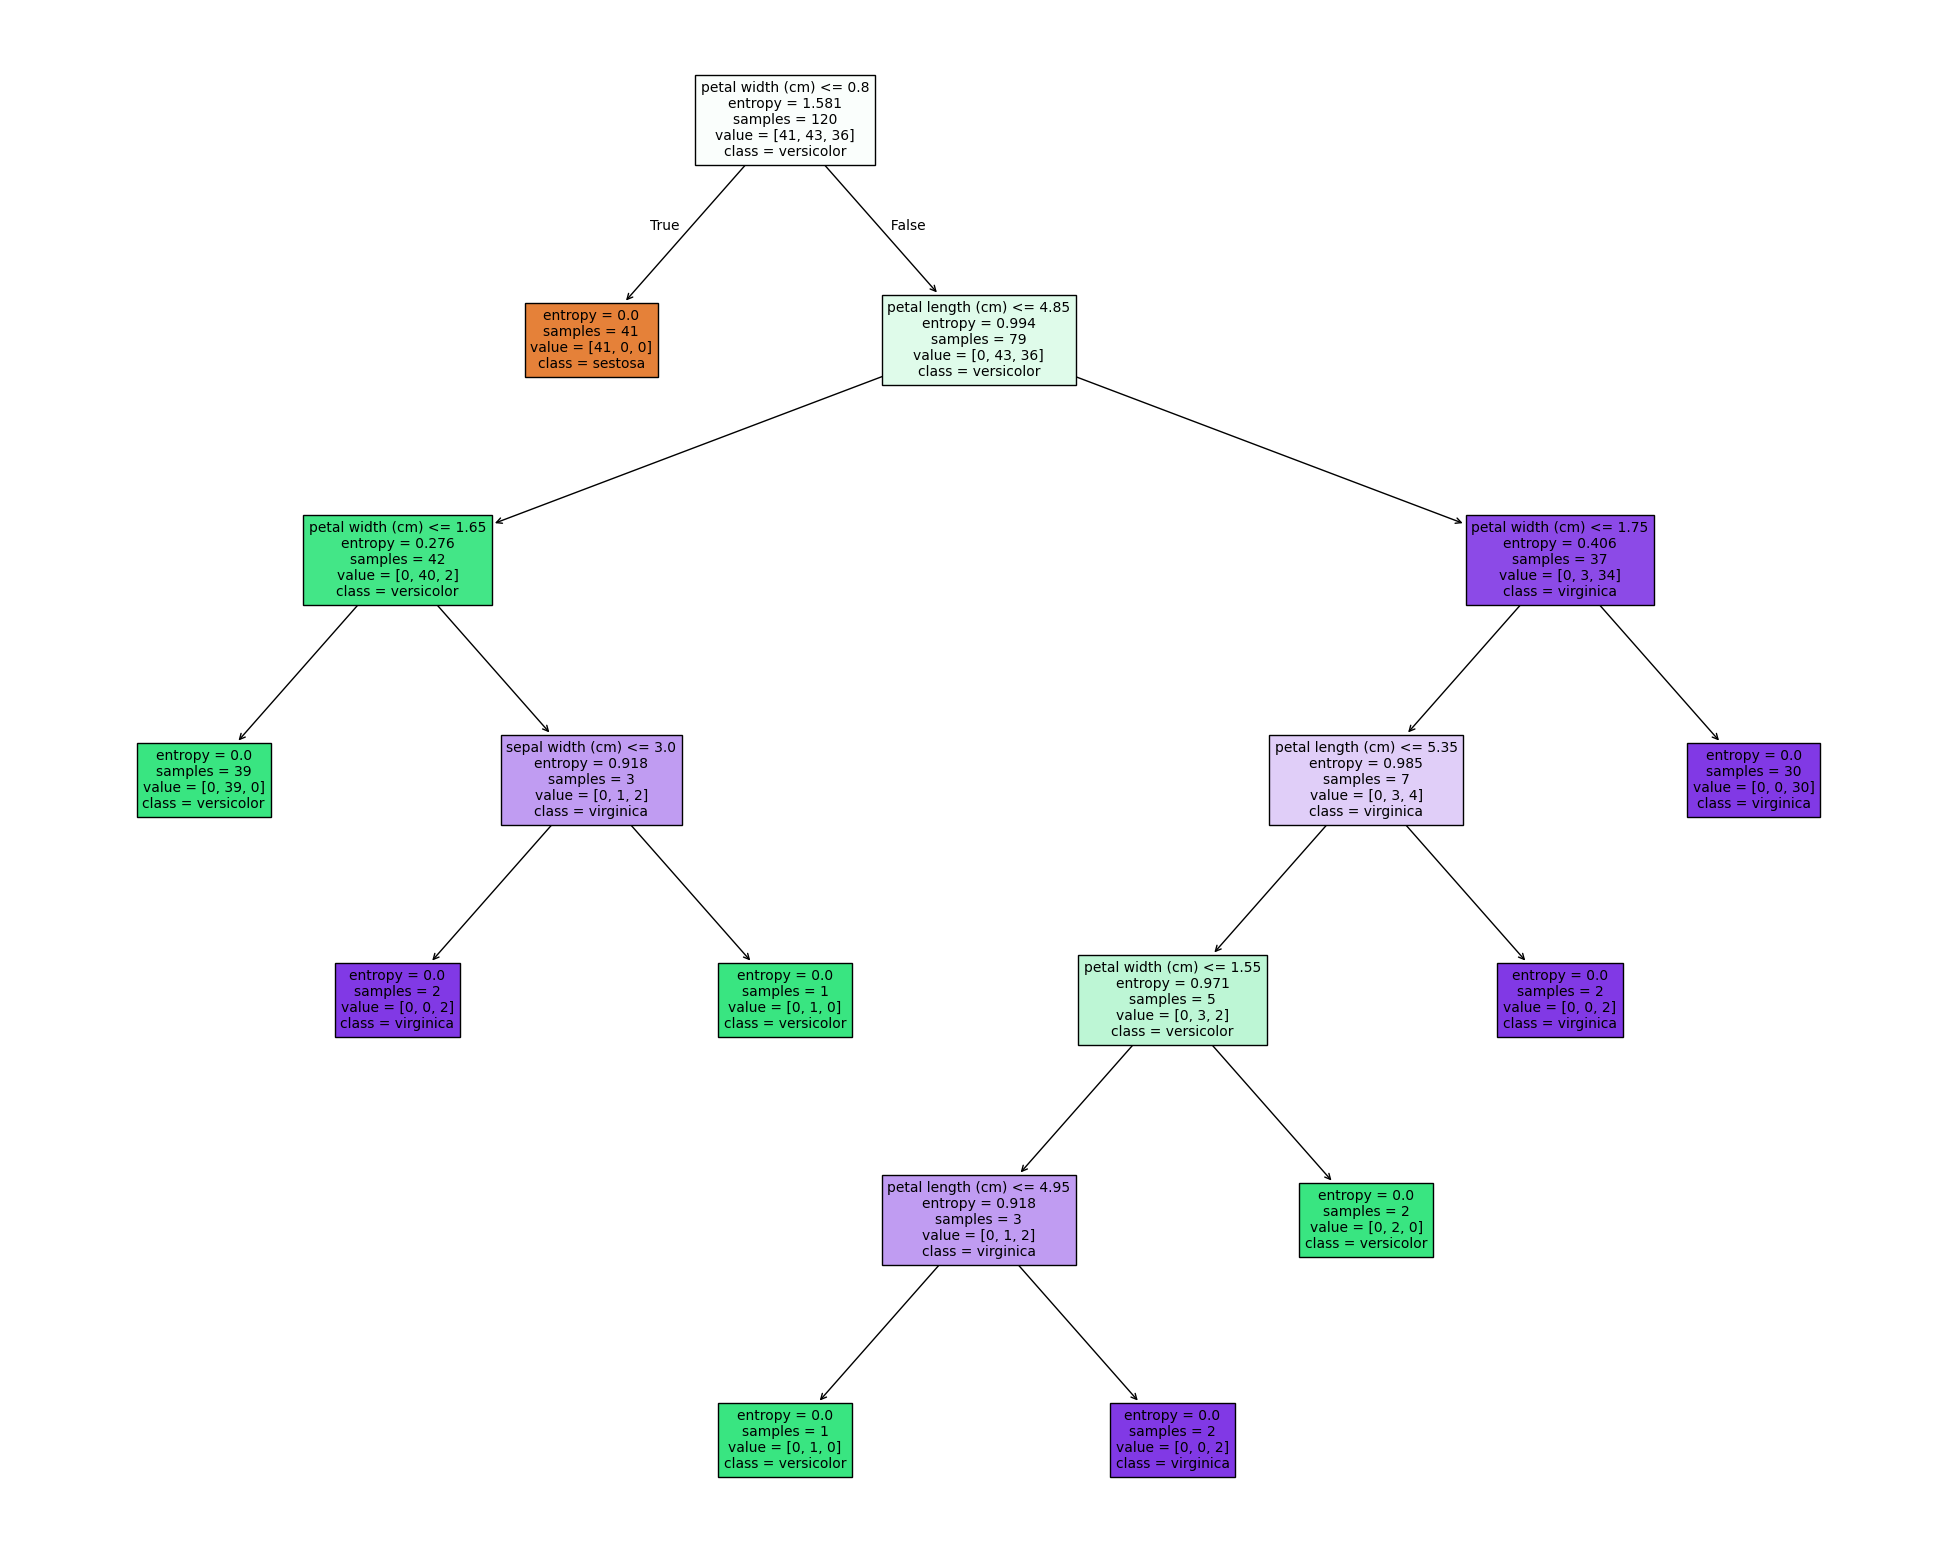

In [41]:
from sklearn import tree
from matplotlib import pyplot as plt


fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(clf,
                   feature_names=feature_names,
                   class_names = {0:'sestosa', 1:'versicolor',2:'virginica'},
                   filled = True,
                   fontsize=10)

In [42]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier()
model_rf = model_rf.fit(X_train, y_train)

In [43]:
model_rf = RandomForestClassifier(n_estimators=40)
model_rf = model_rf.fit(X_train, y_train)
model_rf.score(X_test, y_test)

1.0

In [44]:
predictions_rf = model_rf.predict(X_test)
predictions_rf

array([0, 2, 1, 2, 2, 0, 2, 0, 1, 2, 2, 1, 0, 0, 1, 2, 0, 0, 2, 2, 2, 1,
       2, 1, 1, 2, 0, 2, 0, 2])

In [45]:
comparision_df_rf = pd.DataFrame({'Actual': y_test, 'Predicted': predictions_rf})

comparision_df_rf.head()

,Actual,Predicted
0,0,0
1,2,2
2,1,1
3,2,2
4,2,2


In [46]:
from sklearn.metrics import precision_score
precision_score(y_test, predictions_rf, average='weighted')

1.0

In [48]:
from sklearn.metrics import recall_score
recall_score(y_test, predictions_rf, average='weighted')

1.0

In [49]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, predictions_rf,labels=[0,1,2])

array([[ 9,  0,  0],
       [ 0,  7,  0],
       [ 0,  0, 14]])

In [51]:
from sklearn.metrics import classification_report

print (classification_report(y_test, predictions_rf,target_names = ['setosa', 'versicolor', 'virginica']))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         9
  versicolor       1.00      1.00      1.00         7
   virginica       1.00      1.00      1.00        14

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

